# DVP01: Basic Visualizations (Line & Bar Charts)

La visualización de datos es el puente entre el análisis técnico y la toma de decisiones empresariales. En este cuaderno, aprenderemos a utilizar `matplotlib` en conjunto con DataFrames para crear dos de los gráficos más fundamentales:
1. **Gráficos de Líneas (Line Charts):** Ideales para mostrar tendencias a lo largo del tiempo (Series Temporales).
2. **Gráficos de Barras (Bar Charts):** Perfectos para comparar cantidades entre diferentes categorías.

In [3]:
# Instalación de dependencias (descomentar si es necesario)
# %pip install pandas matplotlib numpy

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configurar la semilla (seed) garantiza que los datos "aleatorios" sean los mismos 
# cada vez que ejecutemos el código, lo cual es vital para la reproductibilidad.
np.random.seed(42)

# Simulamos fechas para el mes de enero de 2026
fechas = pd.date_range(start='2026-01-01', end='2026-01-31')

# Generamos datos de ventas y productos aleatorios
ventas = np.random.randint(50, 200, size=len(fechas))
productos = np.random.choice(['Producto A', 'Producto B', 'Producto C'], size=len(fechas))

# Consolidamos todo en un DataFrame
df_ventas = pd.DataFrame({
    'Fecha': fechas,
    'Ventas': ventas,
    'Producto': productos
})

print("--- Muestra del Dataset de Ventas ---")
display(df_ventas.head())

--- Muestra del Dataset de Ventas ---


,Fecha,Ventas,Producto
0,2026-01-01,152,Producto A
1,2026-01-02,142,Producto C
2,2026-01-03,64,Producto A
3,2026-01-04,156,Producto C
4,2026-01-05,121,Producto C


## 1. Line Charts (Time Series Analysis)
Usamos gráficos de líneas cuando el eje X representa una secuencia cronológica. Nos permite identificar rápidamente picos de ventas, caídas o tendencias de crecimiento.

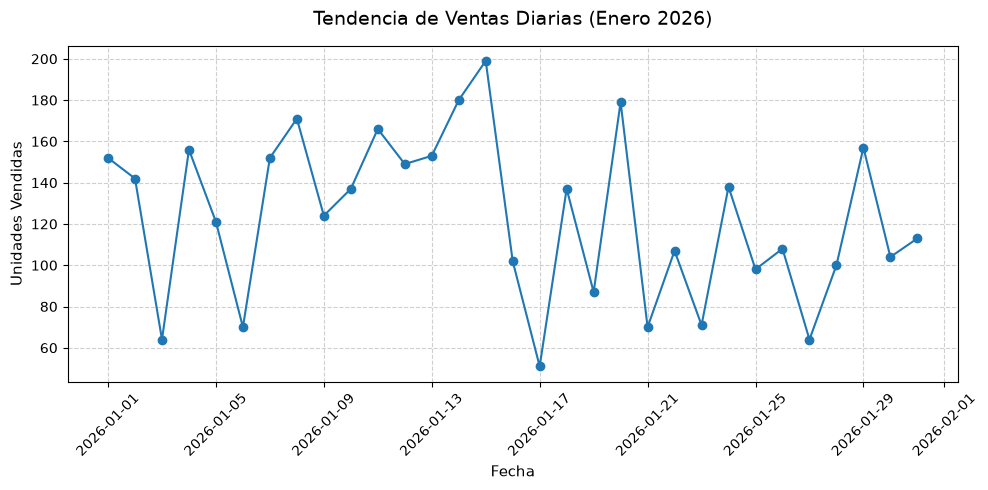

In [4]:
# Paso 1: Agrupar los datos por fecha
ventas_diarias = df_ventas.groupby('Fecha')['Ventas'].sum().reset_index()

# Paso 2: Configurar el lienzo (figure)
plt.figure(figsize=(10, 5)) # Ancho=10, Alto=5

# Paso 3: Trazar el gráfico
plt.plot(
    ventas_diarias['Fecha'], 
    ventas_diarias['Ventas'], 
    marker='o',       # Agrega puntos en cada valor
    color='#1f77b4',  # Color azul corporativo
    linestyle='-'     # Línea continua
)

# Paso 4: Añadir meta-información (Títulos y Etiquetas)
plt.title('Tendencia de Ventas Diarias (Enero 2026)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Unidades Vendidas', fontsize=11)

# Rotamos las fechas para que no se superpongan y activamos la cuadrícula
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajusta automáticamente los márgenes
plt.show()

## 2. Bar Charts (Categorical Comparison)
Cuando el eje X no es tiempo, sino categorías discretas (como marcas, ciudades o productos), el gráfico de barras es la opción correcta para comparar el rendimiento total.

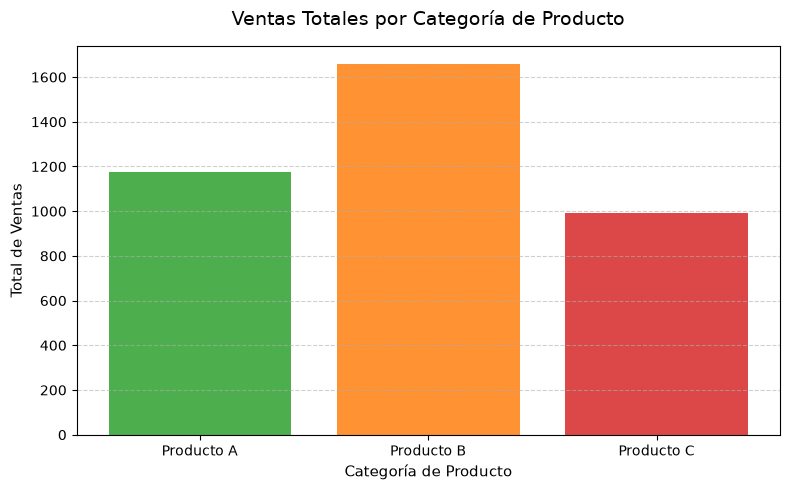

In [5]:
# Paso 1: Agrupar por producto
ventas_por_producto = df_ventas.groupby('Producto')['Ventas'].sum().reset_index()

# Paso 2: Crear el gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(
    ventas_por_producto['Producto'], 
    ventas_por_producto['Ventas'], 
    color=['#2ca02c', '#ff7f0e', '#d62728'], # Un color por producto
    alpha=0.85 # Ligera transparencia
)

plt.title('Ventas Totales por Categoría de Producto', fontsize=14, pad=15)
plt.xlabel('Categoría de Producto', fontsize=11)
plt.ylabel('Total de Ventas', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.6) # Cuadrícula solo horizontal
plt.tight_layout()
plt.show()